In [107]:
#1
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [108]:
#2
df = pd.read_csv("HousingData.csv")

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [109]:
#3
print(df.info())

print("\nDataset Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None

Dataset Shape: (506, 14)


In [110]:
#4
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [111]:
#5
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


skewness = df.skew()

print(skewness.sort_values(ascending=False))

In [112]:
#6
import numpy as np

skewed_features = ['CRIM', 'ZN', 'DIS', 'B', 'LSTAT']

for feature in skewed_features:
    df[feature] = np.log1p(df[feature])

print(df[skewed_features].skew())

CRIM     1.363098
ZN       1.292990
DIS      0.331561
B       -4.459061
LSTAT   -0.212957
dtype: float64


In [113]:
#7
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[~((df < lower) | (df > upper)).any(axis=1)]

print("Dataset Shape After Removing Outliers:", df.shape)

Dataset Shape After Removing Outliers: (252, 14)


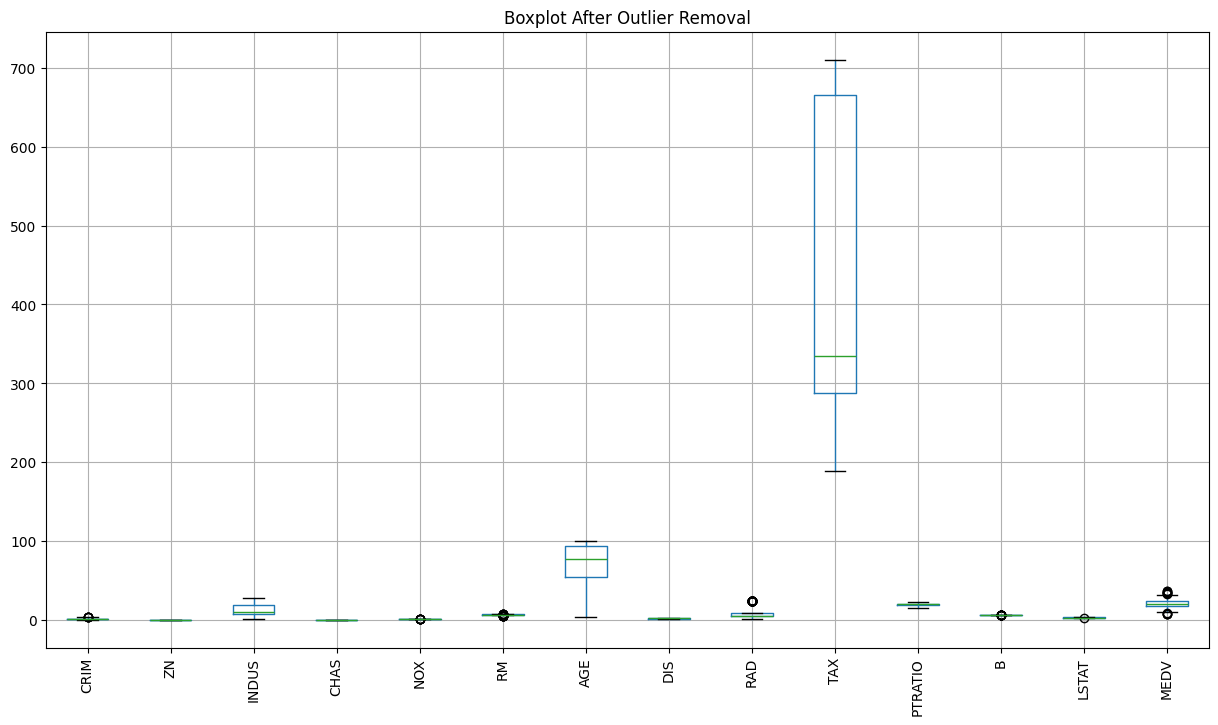

In [114]:
#8
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

df.boxplot(rot=90)

plt.title("Boxplot After Outlier Removal")

plt.show()

In [115]:
#9
X = df.drop("MEDV", axis=1)

y = df["MEDV"]

In [116]:
#10
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [117]:
#11
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [118]:
#12
imputer = SimpleImputer(strategy="median")

df = pd.DataFrame(imputer.fit_transform(df),
                  columns=df.columns)

df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [119]:
#13
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,252.000000,252.0,252.000000,252.0,252.00000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,0.717277,0.0,12.008294,0.0,0.56267,6.130516,71.538492,1.424088,9.007937,406.329365,19.139683,5.965048,2.565786,20.264286
std,0.891437,0.0,6.341264,0.0,0.10198,0.464799,25.366676,0.334193,8.581919,165.376110,1.662719,0.030489,0.419741,5.268942
min,0.024673,0.0,1.250000,0.0,0.41300,4.880000,2.900000,0.776661,1.000000,188.000000,14.700000,5.855444,1.371181,7.200000
25%,0.093697,0.0,7.302500,0.0,0.49300,5.868750,54.150000,1.162479,4.000000,287.000000,17.900000,5.958224,2.309559,17.275000
50%,0.226173,0.0,9.900000,0.0,0.53800,6.121500,76.800000,1.401834,5.000000,334.500000,19.600000,5.977670,2.553693,20.300000
75%,1.215241,0.0,18.100000,0.0,0.61650,6.408250,93.825000,1.687599,8.000000,666.000000,20.200000,5.986201,2.859196,23.100000
max,3.204704,0.0,27.740000,0.0,0.87100,7.416000,100.000000,2.449772,24.000000,711.000000,22.000000,5.986201,3.577110,36.200000


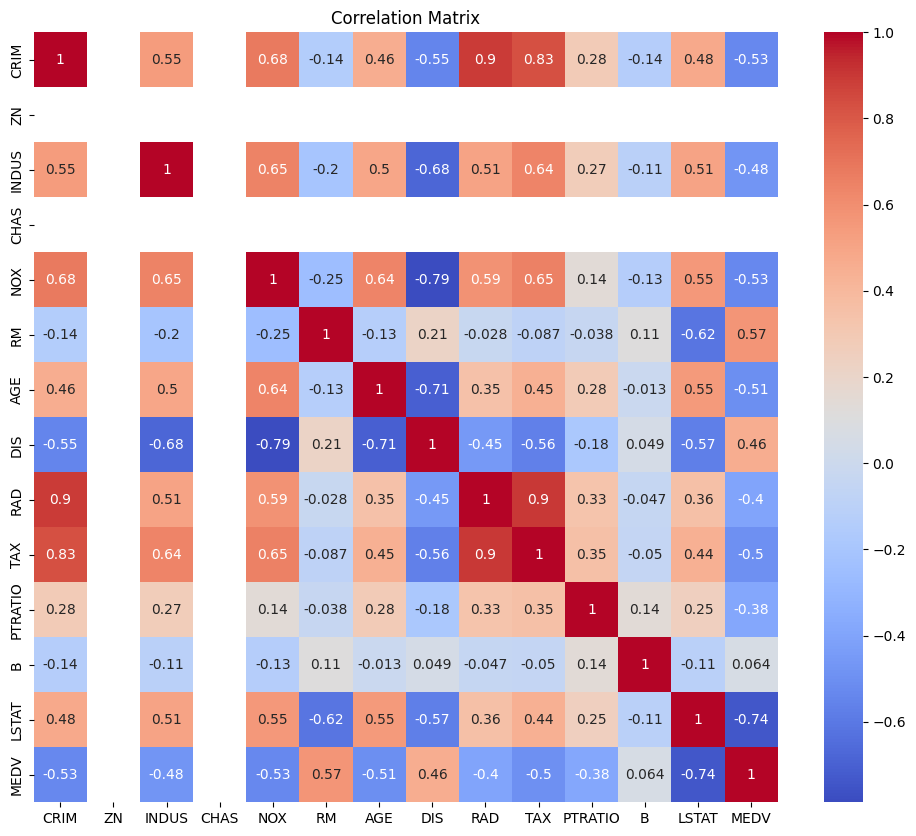

In [120]:
#14
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [121]:
#15
X = df.drop("MEDV", axis=1)

y = df["MEDV"]

In [122]:
#16
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [123]:
#17
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [124]:
#18
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [125]:
#19
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [126]:
#20
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [127]:
#21
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [128]:
#22
def evaluate(model_name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    print(model_name)

    print("MAE :", round(mae,3))

    print("MSE :", round(mse,3))

    print("RMSE:", round(rmse,3))

    print("R2 :", round(r2,3))

    print("-"*40)

In [129]:
#23
evaluate("Linear Regression", y_test, lr_pred)

evaluate("Decision Tree", y_test, dt_pred)

evaluate("Random Forest", y_test, rf_pred)

evaluate("Gradient Boosting", y_test, gb_pred)

Linear Regression
MAE : 1.943
MSE : 6.713
RMSE: 2.591
R2 : 0.723
----------------------------------------
Decision Tree
MAE : 2.061
MSE : 7.152
RMSE: 2.674
R2 : 0.705
----------------------------------------
Random Forest
MAE : 1.771
MSE : 4.705
RMSE: 2.169
R2 : 0.806
----------------------------------------
Gradient Boosting
MAE : 1.563
MSE : 3.83
RMSE: 1.957
R2 : 0.842
----------------------------------------


In [130]:
#24
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 2, 'learning_rate': 0.05}
Best CV Score: 0.7531210309356766


In [131]:
#25
best_model = random_search.best_estimator_

prediction = best_model.predict(X_test)

evaluate("Optimized Gradient Boosting", y_test, prediction)

Optimized Gradient Boosting
MAE : 1.567
MSE : 3.985
RMSE: 1.996
R2 : 0.835
----------------------------------------


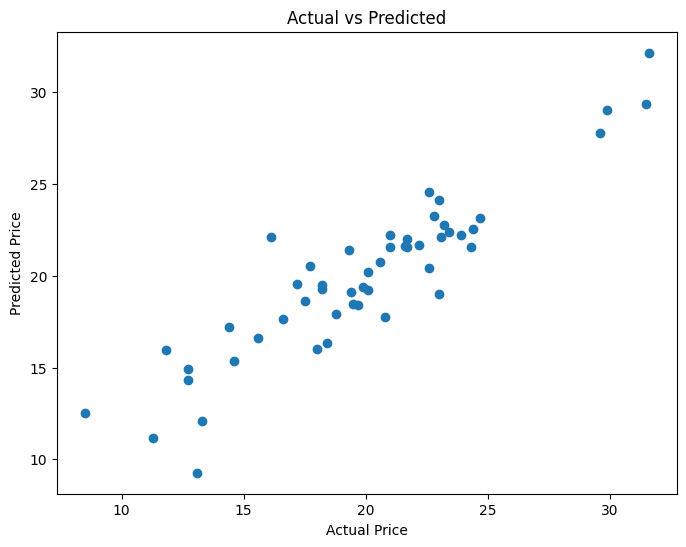

In [132]:
#26
plt.figure(figsize=(8,6))

plt.scatter(y_test, prediction)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [133]:
#27
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
12,LSTAT,0.274631
5,RM,0.189883
6,AGE,0.151928
4,NOX,0.115509
0,CRIM,0.082517
7,DIS,0.070644
9,TAX,0.070410
10,PTRATIO,0.030054
11,B,0.008521
2,INDUS,0.003235


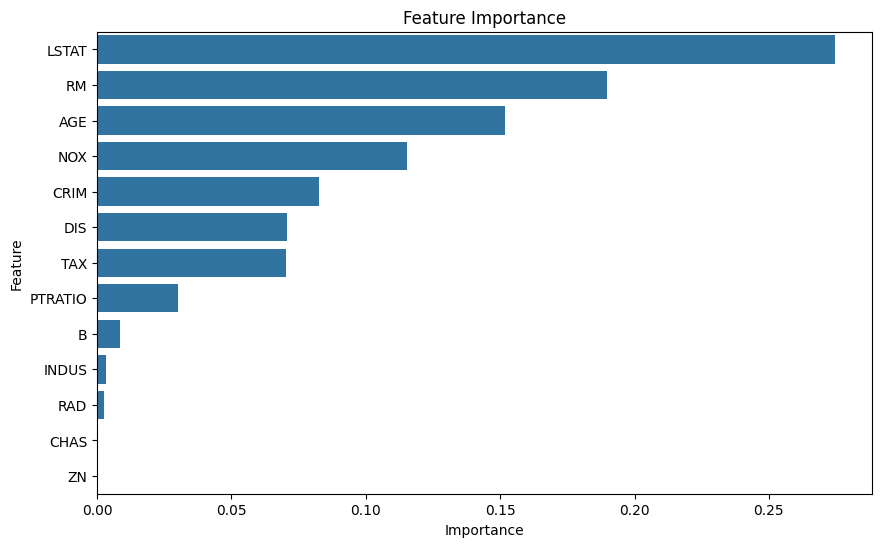

In [134]:
#28
plt.figure(figsize=(10,6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=importance

)

plt.title("Feature Importance")

plt.show()

In [135]:
#29
sample = pd.DataFrame([{
    "CRIM": 0.10,
    "ZN": 18.0,
    "INDUS": 2.31,
    "CHAS": 0,
    "NOX": 0.538,
    "RM": 6.575,
    "AGE": 65.2,
    "DIS": 4.09,
    "RAD": 1,
    "TAX": 296,
    "PTRATIO": 15.3,
    "B": 396.90,
    "LSTAT": 4.98
}])

sample_scaled = scaler.transform(sample)

price = best_model.predict(sample_scaled)

print("Predicted House Price:", round(price[0],2))

Predicted House Price: 19.61


In [136]:
#30
import pickle

# Save the trained model
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save the scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [137]:
#31
import pickle

with open("model.pkl", "rb") as f:
    model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

In [ ]:
#32
import pickle

# Save the trained model
with open("model.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save the scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("✅ model.pkl and scaler.pkl have been created successfully!")

✅ model.pkl and scaler.pkl have been created successfully!
